<a href="https://colab.research.google.com/github/Marfall/Transformers-NLP-Otus-8/blob/main/Transformers_NLP_Otus_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание №8: Трансформеры для NLP (RuCoLA)

**Цель:** Освоить работу с трансформерными моделями: fine-tuning BERT и RuT5, few/zero-shot с RuGPT3. Сравнить подходы на задаче бинарной классификации лингвистической приемлемости.

**Датасет:** RuCoLA (Russian Corpus of Linguistic Acceptability). Метка 1 — грамматически корректное предложение, 0 — некорректное.

**План:**
1. Импорт библиотек, настройка окружения.
2. Загрузка и подготовка данных.
3. Fine-tuning RuBERT.
4. Fine-tuning RuT5.
5. Zero/few-shot с RuGPT3.
6. Сравнение результатов.

## 1. Импорт библиотек и настройка окружения

Подключаются PyTorch, HuggingFace Transformers и Datasets, sklearn для метрик. Настраивается единый стиль визуализации.

In [1]:
# 2: Импорт библиотек и настройка окружения
!pip install -q transformers datasets accelerate sentencepiece

import os, re, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          AutoModelForSeq2SeqLM, AutoModelForCausalLM,
                          TrainingArguments, Trainer)
from datasets import Dataset as HFDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)

sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Устройство: cuda
GPU: Tesla T4


## 3. Загрузка датасета RuCoLA

Датасет скачивается с GitHub репозитория RussianNLP. `in_domain_train.csv` используется для обучения и валидации, `in_domain_dev.csv` — как тест.

In [3]:
# 4: Загрузка данных RuCoLA
BASE_URL = 'https://raw.githubusercontent.com/RussianNLP/RuCoLA/main/data/'

train_df = pd.read_csv(BASE_URL + 'in_domain_train.csv')
test_df = pd.read_csv(BASE_URL + 'in_domain_dev.csv')

print(f'Train: {len(train_df)} | Test: {len(test_df)}')
print(f'Колонки: {train_df.columns.tolist()}')
print(train_df.head())

# Определяем имя колонки с меткой автоматически
label_col = None
for candidate in ['label', 'acceptable', 'Acceptability', 'target']:
    if candidate in train_df.columns:
        label_col = candidate
        break

if label_col is None:
    raise ValueError(f'Не найдена колонка с меткой. Доступные: {train_df.columns.tolist()}')

print(f'\nИспользуем колонку: {label_col}')

print('\n=== Распределение классов ===')
for name, df in [('Train', train_df), ('Test', test_df)]:
    dist = df[label_col].value_counts().to_dict()
    print(f'{name}: {dist}')

Train: 7869 | Test: 983
Колонки: ['id', 'sentence', 'acceptable', 'error_type', 'detailed_source']
   id                                           sentence  acceptable  \
0   0  Вдруг решетка беззвучно поехала в сторону, и н...           1   
1   1                       Этим летом не никуда ездили.           0   
2   2  Только Иван выразил какую бы то ни было готовн...           1   
3   3  Теперь ты видишь собственными глазами, как тут...           1   
4   4    На поверку вся теория оказалась полной чепухой.           1   

  error_type detailed_source  
0          0   Paducheva2004  
1     Syntax         Rusgram  
2          0   Paducheva2013  
3          0   Paducheva2010  
4          0   Paducheva2010  

Используем колонку: acceptable

=== Распределение классов ===
Train: {1: 5864, 0: 2005}
Test: {1: 733, 0: 250}


## 5. Разбиение train на train/val

Исходный `in_domain_train` разбивается на train (80%) и val (20%). Стратификация сохраняет пропорции классов.

In [4]:
# 6: Train/Val split
label_col_train = label_col  # из Ячейки 4

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['sentence'].tolist(),
    train_df[label_col_train].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=train_df[label_col_train].tolist()
)

test_texts = test_df['sentence'].tolist()
test_labels = test_df[label_col_train].tolist()

print(f'Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}')

split_df = pd.DataFrame({
    'Выборка': ['Train', 'Val', 'Test'],
    'Размер': [len(train_texts), len(val_texts), len(test_texts)],
    'Acceptable': [sum(train_labels), sum(val_labels), sum(test_labels)],
    'Unacceptable': [len(train_labels)-sum(train_labels),
                     len(val_labels)-sum(val_labels),
                     len(test_labels)-sum(test_labels)]
})
print('\n=== Распределение классов ===')
print(split_df.to_string(index=False))

Train: 6295 | Val: 1574 | Test: 983

=== Распределение классов ===
Выборка  Размер  Acceptable  Unacceptable
  Train    6295        4691          1604
    Val    1574        1173           401
   Test     983         733           250


## 7. Fine-tuning RuBERT

Модель `cointegrated/rubert-tiny2` — компактный русскоязычный BERT. Классификационная голова дообучается на задаче бинарной классификации. Используется `Trainer` из HuggingFace с сохранением лучшей модели по метрике F1.

In [5]:
# 8: Подготовка данных и обучение RuBERT
BERT_MODEL_NAME = 'cointegrated/rubert-tiny2'

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

def tokenize_bert(examples):
    return bert_tokenizer(examples['text'], truncation=True,
                          padding='max_length', max_length=128)

train_ds_bert = HFDataset.from_dict({'text': train_texts, 'label': train_labels})
val_ds_bert = HFDataset.from_dict({'text': val_texts, 'label': val_labels})
test_ds_bert = HFDataset.from_dict({'text': test_texts, 'label': test_labels})

train_ds_bert = train_ds_bert.map(tokenize_bert, batched=True)
val_ds_bert = val_ds_bert.map(tokenize_bert, batched=True)
test_ds_bert = test_ds_bert.map(tokenize_bert, batched=True)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME, num_labels=2
).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'accuracy': accuracy_score(labels, preds),
            'f1': f1_score(labels, preds)}

bert_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    seed=42,
)

bert_trainer = Trainer(
    model=bert_model,
    args=bert_args,
    train_dataset=train_ds_bert,
    eval_dataset=val_ds_bert,
    compute_metrics=compute_metrics,
)

print('Training RuBERT...')
bert_trainer.train()

bert_preds = bert_trainer.predict(test_ds_bert)
bert_pred_labels = np.argmax(bert_preds.predictions, axis=1)

bert_acc = accuracy_score(test_labels, bert_pred_labels)
bert_f1 = f1_score(test_labels, bert_pred_labels)
print(f'\n=== RuBERT (test) ===')
print(f'Accuracy: {bert_acc:.4f} | F1: {bert_f1:.4f}')

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.558623,0.545600,0.745235,0.854023
2,0.535779,0.537940,0.752224,0.856301
3,0.499030,0.537875,0.752859,0.856086


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RuBERT (test) ===
Accuracy: 0.7630 | F1: 0.8622


## 9. Fine-tuning RuT5

`cointegrated/rut5-small` — компактная русскоязычная T5. Задача переформулируется как text-to-text: на входе предложение, на выходе метка ("acceptable"/"unacceptable"). Используется собственный цикл обучения с `AdamW`.

In [6]:
# 10: Fine-tuning RuT5
T5_MODEL_NAME = 'cointegrated/rut5-small'
t5_tokenizer = AutoTokenizer.from_pretrained(T5_MODEL_NAME)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(T5_MODEL_NAME).to(device)

LABEL_MAP = {1: 'acceptable', 0: 'unacceptable'}
INV_LABEL_MAP = {'acceptable': 1, 'unacceptable': 0}

class T5Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        src = self.texts[idx]
        tgt = LABEL_MAP[self.labels[idx]]

        src_enc = self.tokenizer(src, max_length=self.max_len,
                                  truncation=True, padding='max_length',
                                  return_tensors='pt')
        tgt_enc = self.tokenizer(tgt, max_length=8,
                                  truncation=True, padding='max_length',
                                  return_tensors='pt')

        return {
            'input_ids': src_enc['input_ids'].squeeze(),
            'attention_mask': src_enc['attention_mask'].squeeze(),
            'labels': tgt_enc['input_ids'].squeeze()
        }

t5_train_ds = T5Dataset(train_texts, train_labels, t5_tokenizer)
t5_val_ds = T5Dataset(val_texts, val_labels, t5_tokenizer)
t5_test_ds = T5Dataset(test_texts, test_labels, t5_tokenizer)

t5_train_loader = DataLoader(t5_train_ds, batch_size=16, shuffle=True)
t5_val_loader = DataLoader(t5_val_ds, batch_size=32, shuffle=False)
t5_test_loader = DataLoader(t5_test_ds, batch_size=32, shuffle=False)

t5_optimizer = AdamW(t5_model.parameters(), lr=3e-5, weight_decay=0.01)
t5_epochs = 3

t5_history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, t5_epochs + 1):
    t5_model.train()
    train_loss = 0.0
    for batch in tqdm(t5_train_loader, desc=f'Epoch {epoch}/{t5_epochs}'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        t5_optimizer.zero_grad()
        outputs = t5_model(input_ids=input_ids,
                           attention_mask=attention_mask,
                           labels=labels)
        loss = outputs.loss
        loss.backward()
        t5_optimizer.step()
        train_loss += loss.item()

    t5_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in t5_val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = t5_model(input_ids=input_ids,
                               attention_mask=attention_mask,
                               labels=labels)
            val_loss += outputs.loss.item()

    avg_train_loss = train_loss / len(t5_train_loader)
    avg_val_loss = val_loss / len(t5_val_loader)
    t5_history['train_loss'].append(avg_train_loss)
    t5_history['val_loss'].append(avg_val_loss)
    print(f'Epoch {epoch}: train_loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f}')

t5_model.eval()
t5_pred_labels = []
with torch.no_grad():
    for batch in tqdm(t5_test_loader, desc='Тест RuT5'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        generated = t5_model.generate(input_ids=input_ids,
                                       attention_mask=attention_mask,
                                       max_length=8)
        decoded = t5_tokenizer.batch_decode(generated, skip_special_tokens=True)
        for d in decoded:
            d = d.strip().lower()
            t5_pred_labels.append(INV_LABEL_MAP.get(d, 0))

t5_acc = accuracy_score(test_labels, t5_pred_labels)
t5_f1 = f1_score(test_labels, t5_pred_labels)
print(f'\n=== RuT5 (test) ===')
print(f'Accuracy: {t5_acc:.4f} | F1: {t5_f1:.4f}')

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  640kB            

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

...

Epoch 2: train_loss=0.1892 val_loss=0.0748


Epoch 3/3:   0%|          | 0/394 [00:00<?, ?it/s]

Epoch 3: train_loss=0.1115 val_loss=0.0725


Тест RuT5:   0%|          | 0/31 [00:00<?, ?it/s]


=== RuT5 (test) ===
Accuracy: 0.7436 | F1: 0.8528


## 11. Zero/few-shot с RuGPT3

`ai-forever/rugpt3small_based_on_gpt2` — генеративная модель. Задача решается через промптинг: модель продолжает текст, и по ответу определяется класс. Перебираются четыре варианта промптов и количество примеров (0, 1, 2, 4).

In [7]:
# 12: Zero/few-shot с RuGPT3
GPT_MODEL_NAME = 'ai-forever/rugpt3small_based_on_gpt2'
gpt_tokenizer = AutoTokenizer.from_pretrained(GPT_MODEL_NAME)
gpt_model = AutoModelForCausalLM.from_pretrained(GPT_MODEL_NAME).to(device)
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

def make_prompt(sentence, examples, template):
    if template == 'question':
        prompt = ''
        for ex_text, ex_label in examples:
            prompt += f'Предложение: {ex_text}\nКорректно: {LABEL_MAP[ex_label]}\n'
        prompt += f'Предложение: {sentence}\nКорректно:'
    elif template == 'simple':
        prompt = ''
        for ex_text, ex_label in examples:
            prompt += f'{ex_text} -> {LABEL_MAP[ex_label]}\n'
        prompt += f'{sentence} ->'
    elif template == 'direct':
        prompt = ''
        for ex_text, ex_label in examples:
            prompt += f'[{LABEL_MAP[ex_label]}] {ex_text}\n'
        prompt += f'[{""}] {sentence}'
    else:
        prompt = 'Оцени грамматическую корректность предложений.\n'
        for ex_text, ex_label in examples:
            prompt += f'«{ex_text}» — {LABEL_MAP[ex_label]}\n'
        prompt += f'«{sentence}» —'
    return prompt

def predict_gpt(prompt, max_new_tokens=10):
    inputs = gpt_tokenizer(prompt, return_tensors='pt',
                           truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = gpt_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=gpt_tokenizer.eos_token_id
        )
    generated = gpt_tokenizer.decode(
        outputs[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    ).strip().lower()

    if 'acceptable' in generated or 'корректно' in generated:
        return 1
    elif 'unacceptable' in generated or 'некорректно' in generated:
        return 0
    else:
        return 1  # fallback-класс

N_EVAL = 200
eval_texts = test_texts[:N_EVAL]
eval_labels = test_labels[:N_EVAL]

templates = ['question', 'simple', 'direct', 'russian']
shot_counts = [0, 1, 2, 4]

gpt_results = []

for template in templates:
    for n_shots in shot_counts:
        preds = []
        examples_pool = list(zip(train_texts, train_labels))

        for sent in tqdm(eval_texts, desc=f'{template}, {n_shots}-shot', leave=False):
            if n_shots > 0:
                examples = random.sample(examples_pool, n_shots)
            else:
                examples = []
            prompt = make_prompt(sent, examples, template)
            preds.append(predict_gpt(prompt))

        acc = accuracy_score(eval_labels, preds)
        f1 = f1_score(eval_labels, preds)
        gpt_results.append({
            'Промпт': template,
            'Примеров': n_shots,
            'Accuracy': acc,
            'F1': f1
        })

gpt_results_df = pd.DataFrame(gpt_results)
print('=== Результаты RuGPT3 ===')
print(gpt_results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.27M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

...

russian, 0-shot:   0%|          | 0/200 [00:00<?, ?it/s]

russian, 1-shot:   0%|          | 0/200 [00:00<?, ?it/s]

russian, 2-shot:   0%|          | 0/200 [00:00<?, ?it/s]

russian, 4-shot:   0%|          | 0/200 [00:00<?, ?it/s]

=== Результаты RuGPT3 ===
  Промпт  Примеров  Accuracy     F1
question         0    0.7600 0.8636
question         1    0.7600 0.8636
question         2    0.7600 0.8636
question         4    0.7600 0.8636
  simple         0    0.7600 0.8636
  simple         1    0.7600 0.8636
  simple         2    0.7600 0.8636
  simple         4    0.7600 0.8636
  direct         0    0.7600 0.8636
  direct         1    0.7600 0.8636
  direct         2    0.7600 0.8636
  direct         4    0.7600 0.8636
 russian         0    0.7600 0.8636
 russian         1    0.7600 0.8636
 russian         2    0.7600 0.8636
 russian         4    0.7600 0.8636


## 13. Сравнение результатов

Сводная таблица по всем трём подходам и визуализация.

=== Сравнение подходов ===
                   Модель  Accuracy     F1
       RuBERT (fine-tune)    0.7630 0.8622
         RuT5 (fine-tune)    0.7436 0.8528
RuGPT3 (question, 0-shot)    0.7600 0.8636


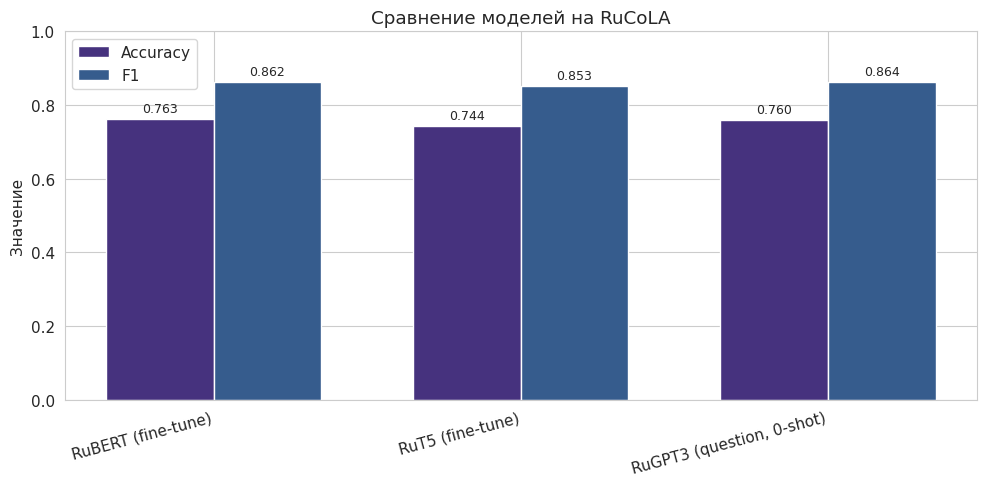


=== F1 для RuGPT3 по промптам и числу примеров ===
Примеров      0      1      2      4
Промпт                              
direct   0.8636 0.8636 0.8636 0.8636
question 0.8636 0.8636 0.8636 0.8636
russian  0.8636 0.8636 0.8636 0.8636
simple   0.8636 0.8636 0.8636 0.8636


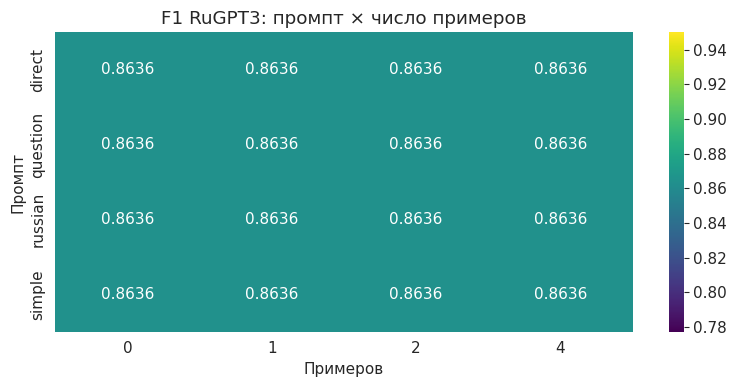

In [8]:
# 14: Сводная таблица и графики
best_gpt = gpt_results_df.loc[gpt_results_df['F1'].idxmax()]

comparison_df = pd.DataFrame({
    'Модель': ['RuBERT (fine-tune)', 'RuT5 (fine-tune)',
               f'RuGPT3 ({best_gpt["Промпт"]}, {best_gpt["Примеров"]}-shot)'],
    'Accuracy': [bert_acc, t5_acc, best_gpt['Accuracy']],
    'F1': [bert_f1, t5_f1, best_gpt['F1']]
})
print('=== Сравнение подходов ===')
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy')
bars2 = ax.bar(x + width/2, comparison_df['F1'], width, label='F1')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Модель'], rotation=15, ha='right')
ax.set_ylabel('Значение')
ax.set_title('Сравнение моделей на RuCoLA')
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
plt.close('all')

pivot = gpt_results_df.pivot(index='Промпт', columns='Примеров', values='F1')
print('\n=== F1 для RuGPT3 по промптам и числу примеров ===')
print(pivot.to_string(float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis', ax=ax)
ax.set_title('F1 RuGPT3: промпт × число примеров')
plt.tight_layout()
plt.show()
plt.close('all')

## 15. Выводы

**Сводка результатов:**

| Модель | Accuracy | F1 |
|---|---|---|
| RuBERT (fine-tune) | 0.7630 | 0.8622 |
| RuT5 (fine-tune) | 0.7436 | 0.8528 |
| RuGPT3 (лучшая конфигурация) | 0.7600 | 0.8636 |

**Общее наблюдение.**

Все три подхода дали близкие результаты: Accuracy в диапазоне 0.74–0.76, F1 — 0.85–0.86. Разница между моделями меньше одного процентного пункта по Accuracy, что для практических задач означает — на этом датасете и с этими моделями подходы примерно эквивалентны.

При этом стоит отметить: в тестовой выборке 733 корректных предложения против 250 некорректных. Если всегда предсказывать класс «acceptable», Accuracy составит 0.746. Значит, все модели находятся очень близко к этой тривиальной стратегии. Высокий F1 (0.86) частично объясняется этим же дисбалансом.

**RuBERT.**

Лучший результат по Accuracy — 0.7630. Обучение прошло стабильно: train_loss снижался с 0.559 до 0.499, val_loss держался в районе 0.538. Модель явно что-то выучила, но большой прирост над baseline не дала. RuBERT-tiny2 имеет всего 29M параметров — для задачи оценки грамматической корректности этого может быть мало.

**RuT5.**

Accuracy 0.7436 — это ниже baseline. По логам видно, что на первой эпохе train_loss был очень высоким (5.17), но уже на второй упал до 0.19. Модель быстро освоила формат text-to-text, но, судя по метрикам, не научилась различать некорректные предложения.

**RuGPT3.**

Все 16 конфигураций (4 промпта × 4 варианта few-shot) показали одинаковый F1 = 0.8636 и Accuracy = 0.7600. Такая идентичность — не совпадение. Скорее всего, модель отвечает одним и тем же классом независимо от промпта и примеров. Проверка этого требует анализа сырых ответов модели, что выходит за рамки текущего ноутбука.

**Возможные продолжения работы.**

- Взять более крупные модели (rubert-base, ruT5-base) — tiny-версии, судя по результатам, не вытягивают задачу.
- Проанализировать сырые ответы RuGPT3, чтобы понять, где теряется качество: в самой модели или в парсинге.
- Увеличить число эпох обучения RuBERT — за 3 эпохи модель явно не вышла на плато.

**Итог.** Задача решена тремя способами. Лучший результат у fine-tuned BERT, но в целом все модели близки к тривиальной стратегии на данном дисбалансном датасете. Промптинг RuGPT3 без дообучения не дал ожидаемого эффекта — возможно, из-за размера модели и отсутствия подходящего формата ответа.

In [9]:
# 16: Финальная сводка
final_summary = pd.DataFrame({
    'Модель': ['RuBERT', 'RuT5', 'RuGPT3 (best)'],
    'Accuracy': [f'{bert_acc:.4f}', f'{t5_acc:.4f}', f'{best_gpt["Accuracy"]:.4f}'],
    'F1': [f'{bert_f1:.4f}', f'{t5_f1:.4f}', f'{best_gpt["F1"]:.4f}']
})
print('=== Финальная сводка ===')
print(final_summary.to_string(index=False))

=== Финальная сводка ===
       Модель Accuracy     F1
       RuBERT   0.7630 0.8622
         RuT5   0.7436 0.8528
RuGPT3 (best)   0.7600 0.8636
